# Building a Soccer Team for RoboCup (Simulation League)

In [1]:
import random, math
from collections import defaultdict, deque
import numpy as np
import matplotlib.pyplot as plt

Self-play grid soccer with BDI-flavored roles + tabular Q-learning.

- 8x5 field, two teams (Left/Right) with 4 roles each: Free-kick-taker (FKT), Attacker (ATT), Defender (DEF), Player (PLY).
- Actions: STAY, N, S, E, W, PASS, SHOOT, TACKLE
- Rewards: +1 goal, -1 conceded, tiny shaping for progress/possession regain, small step cost
- Both teams learn online every step (self-evolving).

In [2]:
# Environment
GRID_W, GRID_H = 8, 5
LEFT_GOAL_X, RIGHT_GOAL_X = 0, GRID_W - 1

ROLES = [
         "FKT", # Free-kick-taker
         "ATT", # Attacker
         "DEF", # Defender
         "PLY"  #  Player
        ]       
ACTIONS = ["STAY", "N", "S", "E", "W", "PASS", "SHOOT", "TACKLE"]

def clip(v, lo, hi): 
    return max(lo, min(hi, v))

class Team:
    def __init__(self, name, side):
        self.name = name
        self.side = side                     # 'L' or 'R'
        self.players = []
        # spawn roughly in own half; order: FKT, ATT, DEF, PLY
        if side == 'L':
            xs = [1, 3, 2, 2]; ys = [0, 2, 2, 4]
        else:
            xs = [GRID_W-2, GRID_W-4, GRID_W-3, GRID_W-3]; ys = [GRID_H-1, 2, 2, 0]
        for role, x, y in zip(ROLES, xs, ys):
            self.players.append({"role": role, "x": clip(x,0,GRID_W-1), "y": clip(y,0,GRID_H-1)})


In [3]:
class SoccerEnv:
    """
    Very light rules to keep training fast:
    - Possession: ball has an 'owner' team 'L'/'R' or None (loose). If owned, it snaps to the closest player of that team.
    - PASS: sends ball to nearest open teammate (teleports for simplicity).
    - SHOOT: probabilistic goal based on distance to opponent goal line.
    - TACKLE: succeeds with 0.7 prob if within Manhattan distance <= 1; steals the ball.
    - A single goal ends the episode.
    """
    def __init__(self, seed=0):
        random.seed(seed); np.random.seed(seed)
        self.reset()

    def reset(self):
        self.tL = Team("Blue",  'L')
        self.tR = Team("Red",   'R')
        self.ball = {"x": GRID_W//2, "y": GRID_H//2, "owner": random.choice(["L","R",None])}
        self.steps = 0
        return self._obs()

    def _nearest(self, players, x, y, exclude=None):
        best = None; best_d = 1e9
        for p in players:
            if exclude is not None and p is exclude: 
                continue
            d = abs(p["x"]-x) + abs(p["y"]-y)
            if d < best_d:
                best_d = d; best = p
        return best, best_d

    def _move_one(self, player, a):
        dx=dy=0
        if   a=="N": dy=-1
        elif a=="S": dy= 1
        elif a=="E": dx= 1
        elif a=="W": dx=-1
        player["x"] = clip(player["x"]+dx, 0, GRID_W-1)
        player["y"] = clip(player["y"]+dy, 0, GRID_H-1)

    def _obs(self):
        """
        Return per-team, per-role abstract state:
        s = (progress_bucket, vertical_bucket, possession_code, role_code, side_sign)
        """
        def team_states(side):
            bx, by = self.ball["x"], self.ball["y"]
            side_sign = 1 if side=='L' else -1
            progress = side_sign * (bx - (GRID_W//2))
            prog_b = int(np.clip(math.floor(progress/1.0), -2, 2))
            vert_b = int(np.clip(by - GRID_H//2, -2, 2))
            poss = self.ball["owner"]
            poss_code = 0 if poss is None else (1 if poss==side else -1)
            states = {}
            for idx, role in enumerate(ROLES):
                states[role] = (prog_b, vert_b, poss_code, idx, side_sign)
            return states
        return {"L": team_states('L'), "R": team_states('R')}

    def step(self, acts_L, acts_R):
        self.steps += 1
        reward_L = reward_R = 0.0
        done = False

        # 1) Movement
        for role, a in acts_L.items():
            if a in ("N","S","E","W"):
                self._move_one(self.tL.players[ROLES.index(role)], a)
        for role, a in acts_R.items():
            if a in ("N","S","E","W"):
                self._move_one(self.tR.players[ROLES.index(role)], a)

        # 2) Resolve possession snap to owner
        for side, team in (('L', self.tL), ('R', self.tR)):
            if self.ball["owner"] == side:
                owner, _ = self._nearest(team.players, self.ball["x"], self.ball["y"])
                self.ball["x"], self.ball["y"] = owner["x"], owner["y"]

        # 3) Actions that affect ball: PASS/SHOOT/TACKLE per team
        for side, acts in (('L', acts_L), ('R', acts_R)):
            team = self.tL if side=='L' else self.tR
            opp  = self.tR if side=='L' else self.tL
            goal_x = RIGHT_GOAL_X if side=='L' else LEFT_GOAL_X
            side_sign = 1 if side=='L' else -1

            # Owner if any
            owner = None
            if self.ball["owner"] == side:
                owner, _ = self._nearest(team.players, self.ball["x"], self.ball["y"])

            # PASS
            if owner is not None and acts.get(owner["role"], "STAY") == "PASS":
                mate, _ = self._nearest(team.players, owner["x"], owner["y"], exclude=owner)
                self.ball["x"], self.ball["y"] = mate["x"], mate["y"]
                self.ball["owner"] = side
                # tiny shaping for pushing ball forward
                progress = side_sign * (self.ball["x"] - (GRID_W//2))
                rshape = 0.02 * progress
                if side=='L': reward_L += rshape
                else:         reward_R += rshape

            # SHOOT
            if owner is not None and acts.get(owner["role"], "STAY") == "SHOOT":
                # distance to opponent goal: closer = higher prob
                dist = abs(owner["x"] - goal_x)
                p_goal = 0.25 + 0.12 * (3 - min(dist,3))   # 0.25 .. 0.61 approx
                if random.random() < p_goal:
                    if side=='L': reward_L += 1.0; reward_R -= 1.0
                    else:         reward_R += 1.0; reward_L -= 1.0
                    return self._obs(), (reward_L, reward_R), True
                else:
                    # miss → ball goes one cell forward, becomes loose
                    nx = clip(owner["x"] + side_sign, 0, GRID_W-1)
                    self.ball["x"], self.ball["y"] = nx, owner["y"]
                    self.ball["owner"] = None

            # TACKLE attempts (when not owning ball or ball loose)
            if self.ball["owner"] != side:
                for p in team.players
                    if acts.get(p["role"], "STAY") == "TACKLE":
                        d = abs(p["x"]-self.ball["x"]) + abs(p["y"]-self.ball["y"])
                        if d <= 1 and random.random() < 0.7:
                            self.ball["owner"] = side
                            self.ball["x"], self.ball["y"] = p["x"], p["y"]
                            if side=='L': reward_L += 0.05
                            else:         reward_R += 0.05

        # 4) Goal if ball crosses goal line (loose)
        if self.ball["x"] == LEFT_GOAL_X:
            reward_R += 1.0; reward_L -= 1.0; done = True
        elif self.ball["x"] == RIGHT_GOAL_X:
            reward_L += 1.0; reward_R -= 1.0; done = True

        # 5) Small step penalty to encourage faster play
        reward_L -= 0.001; reward_R -= 0.001

        return self._obs(), (reward_L, reward_R), done

In [4]:
# Q-learning agents
class RoleQPolicy:
    def __init__(self, epsilon=0.25, alpha=0.2, gamma=0.95):
        self.Q = defaultdict(lambda: np.zeros(len(ACTIONS), dtype=np.float32))
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma

    def act(self, s):
        if random.random() < self.epsilon:
            return random.randrange(len(ACTIONS))
        q = self.Q[s]
        return int(np.argmax(q))

    def update(self, s, a, r, s_next, done):
        q = self.Q[s]
        target = r if done else r + self.gamma * np.max(self.Q[s_next])
        q[a] += self.alpha * (target - q[a])

In [5]:
class TeamAgent:
    """Shared policy per role; learn online every step (self-evolving)."""
    def __init__(self, side):
        self.side = side
        self.role_policies = {role: RoleQPolicy() for role in ROLES}

    def choose_actions(self, role_states):
        acts = {}
        for role in ROLES:
            s = role_states[role]
            a_idx = self.role_policies[role].act(s)
            acts[role] = ACTIONS[a_idx]
        return acts

    def learn(self, s_roles, a_roles, r_team, s_roles_next, done):
        for role in ROLES:
            s = s_roles[role]
            a_idx = ACTIONS.index(a_roles[role])
            s_next = s_roles_next[role]
            self.role_policies[role].update(s, a_idx, r_team, s_next, done)




In [6]:
def evaluate(agent_L, agent_R, episodes=60, max_steps=80, seed=123):
    """Run without learning to estimate current strength: returns win rate for L & R."""
    rng_state = random.getstate(); np_state = np.random.get_state()
    random.seed(seed); np.random.seed(seed)

    env = SoccerEnv(seed=seed)
    winsL=winsR=draws=0
    for _ in range(episodes):
        obs = env.reset()
        sL, sR = obs["L"], obs["R"]
        for t in range(max_steps):
            # greedy acts (epsilon = 0)
            aL = {role: ACTIONS[int(np.argmax(agent_L.role_policies[role].Q[sL[role]]))] for role in ROLES}
            aR = {role: ACTIONS[int(np.argmax(agent_R.role_policies[role].Q[sR[role]]))] for role in ROLES}
            obs2, (rL, rR), done = env.step(aL, aR)
            sL, sR = obs2["L"], obs2["R"]
            if done:
                if rL>rR: winsL += 1
                elif rR>rL: winsR += 1
                else: draws += 1
                break
    # restore rng
    random.setstate(rng_state); np.random.set_state(np_state)
    total = max(1, winsL+winsR+draws)
    return winsL/total, winsR/total, draws/total


In [7]:
def train_self_play(episodes=500, max_steps=80, eval_every=50, seed=7):
    env = SoccerEnv(seed=seed)
    agent_L = TeamAgent('L')
    agent_R = TeamAgent('R')

    wrL_hist, wrR_hist = [], []
    win_hist_L, win_hist_R = [], []
    window = 50

    for ep in range(1, episodes+1):
        # epsilon decay (both sides)
        for rp in agent_L.role_policies.values():
            rp.epsilon = max(0.05, rp.epsilon * 0.995)
        for rp in agent_R.role_policies.values():
            rp.epsilon = max(0.05, rp.epsilon * 0.995)

        obs = env.reset()
        sL, sR = obs["L"], obs["R"]
        total_rL = total_rR = 0.0

        for t in range(max_steps):
            aL = agent_L.choose_actions(sL)
            aR = agent_R.choose_actions(sR)
            obs2, (rL, rR), done = env.step(aL, aR)
            sL2, sR2 = obs2["L"], obs2["R"]

            # learn (every round)
            agent_L.learn(sL, aL, rL, sL2, done)
            agent_R.learn(sR, aR, rR, sR2, done)

            sL, sR = sL2, sR2
            total_rL += rL; total_rR += rR
            if done: break

        # episode outcome
        if total_rL > total_rR: win_hist_L.append(1); win_hist_R.append(0)
        elif total_rR > total_rL: win_hist_L.append(0); win_hist_R.append(1)
        else: win_hist_L.append(0); win_hist_R.append(0)

        # moving win-rate
        wrL = sum(win_hist_L[-window:]) / min(window, len(win_hist_L))
        wrR = sum(win_hist_R[-window:]) / min(window, len(win_hist_R))
        wrL_hist.append(wrL); wrR_hist.append(wrR)

        # periodic evaluation with greedy policies (no exploration)
        if ep % eval_every == 0:
            eL, eR, eD = evaluate(agent_L, agent_R, episodes=80)
            print(f"[Eval @ ep {ep}] Greedy win rates  L:{eL:.2f}  R:{eR:.2f}  Draw:{eD:.2f}")

    return {"agent_L": agent_L, "agent_R": agent_R,
            "wrL_hist": wrL_hist, "wrR_hist": wrR_hist,
            "win_hist_L": win_hist_L, "win_hist_R": win_hist_R}

In [8]:
results = train_self_play(episodes=500, max_steps=80, eval_every=100, seed=7)

[Eval @ ep 100] Greedy win rates  L:0.65  R:0.35  Draw:0.00
[Eval @ ep 200] Greedy win rates  L:0.58  R:0.42  Draw:0.00
[Eval @ ep 300] Greedy win rates  L:0.74  R:0.26  Draw:0.00
[Eval @ ep 400] Greedy win rates  L:0.25  R:0.75  Draw:0.00
[Eval @ ep 500] Greedy win rates  L:0.89  R:0.11  Draw:0.00


In [9]:
def show_winrate(wrL_hist, wrR_hist):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    plt.plot(wrL_hist, label="Team L (Blue) moving win-rate")
    plt.plot(wrR_hist, label="Team R (Red) moving win-rate")
    plt.title("Self-Play RL: Teams Learn Over Time (window=50 episodes)")
    plt.xlabel("Episode"); plt.ylabel("Win-Rate"); plt.legend(); plt.tight_layout()
    plt.show()

[Eval @ ep 100] Greedy win rates  L:0.65  R:0.35  Draw:0.00
[Eval @ ep 200] Greedy win rates  L:0.58  R:0.42  Draw:0.00
[Eval @ ep 300] Greedy win rates  L:0.74  R:0.26  Draw:0.00
[Eval @ ep 400] Greedy win rates  L:0.25  R:0.75  Draw:0.00
[Eval @ ep 500] Greedy win rates  L:0.89  R:0.11  Draw:0.00


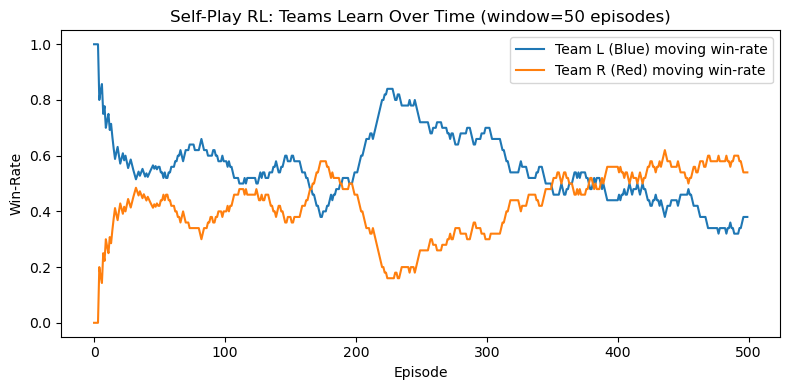

In [10]:
# Training
results = train_self_play(episodes=500, max_steps=80, eval_every=100, seed=7)

show_winrate(results["wrL_hist"], results["wrR_hist"])

## Other visualizations

In [11]:
def show_cumulative_wins(win_hist_L, win_hist_R):
    import matplotlib.pyplot as plt, numpy as np
    L = np.cumsum(win_hist_L); R = np.cumsum(win_hist_R)
    plt.figure(figsize=(8,4))
    plt.plot(L, label="Team L cumulative wins")
    plt.plot(R, label="Team R cumulative wins")
    plt.xlabel("Episode"); plt.ylabel("Cumulative wins")
    plt.title("Cumulative Wins Over Training")
    plt.legend(); plt.tight_layout(); plt.show()


In [12]:
def show_action_mix(agent, title="Team action mix by role"):
    import matplotlib.pyplot as plt, numpy as np
    ROLES = ["FKT", "ATT", "DEF", "PLY"]
    ACTIONS = ["STAY","N","S","E","W","PASS","SHOOT","TACKLE"]
    counts = np.zeros((len(ROLES), len(ACTIONS)), dtype=int)
    for r_idx, role in enumerate(ROLES):
        Q = agent.role_policies[role].Q
        for s, q in Q.items():
            counts[r_idx, int(np.argmax(q))] += 1
    plt.figure(figsize=(9,4.5))
    for r_idx, role in enumerate(ROLES):
        plt.subplot(1,4,r_idx+1)
        plt.bar(range(len(ACTIONS)), counts[r_idx])
        plt.xticks(range(len(ACTIONS)), ACTIONS, rotation=90)
        plt.title(role)
    plt.suptitle(title); plt.tight_layout(); plt.show()


In [13]:
def play_one_greedy_episode(agent_L, agent_R, max_steps=120, seed=123):
    env = SoccerEnv(seed=seed)
    obs = env.reset(); sL, sR = obs["L"], obs["R"]
    log = {"ball_xy": []}
    for _ in range(max_steps):
        aL = {role: ACTIONS[int(np.argmax(agent_L.role_policies[role].Q[sL[role]]))] for role in ROLES}
        aR = {role: ACTIONS[int(np.argmax(agent_R.role_policies[role].Q[sR[role]]))] for role in ROLES}
        log["ball_xy"].append((env.ball["x"], env.ball["y"]))
        obs2, _, done = env.step(aL, aR)
        sL, sR = obs2["L"], obs2["R"]
        if done: break
    return log

def show_ball_heatmap(run_log):
    import numpy as np, matplotlib.pyplot as plt
    xs = [x for x,y in run_log["ball_xy"]]; ys = [y for x,y in run_log["ball_xy"]]
    H, _, _ = np.histogram2d(xs, ys, bins=[GRID_W, GRID_H], range=[[0,GRID_W],[0,GRID_H]])
    plt.figure(figsize=(6,3.6))
    plt.imshow(H.T, origin="lower", aspect="auto")
    plt.colorbar(label="frequency")
    plt.xticks(range(GRID_W)); plt.yticks(range(GRID_H))
    plt.title("Ball Occupancy Heatmap (one greedy episode)")
    plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()


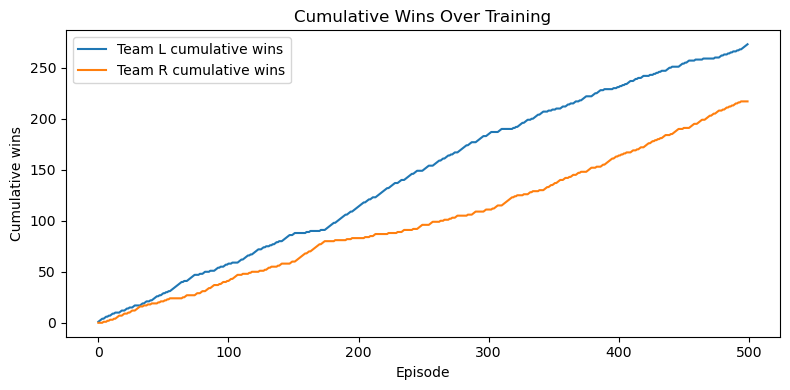

In [14]:
show_cumulative_wins(results["win_hist_L"], results["win_hist_R"])


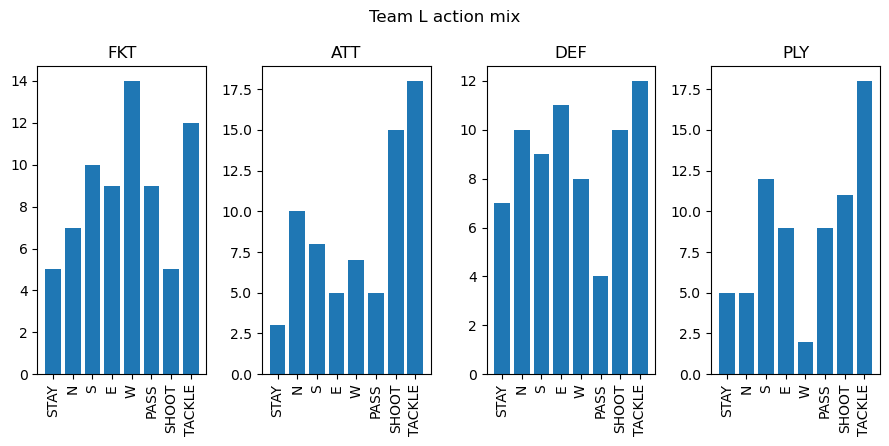

In [15]:
show_action_mix(results["agent_L"], "Team L action mix")


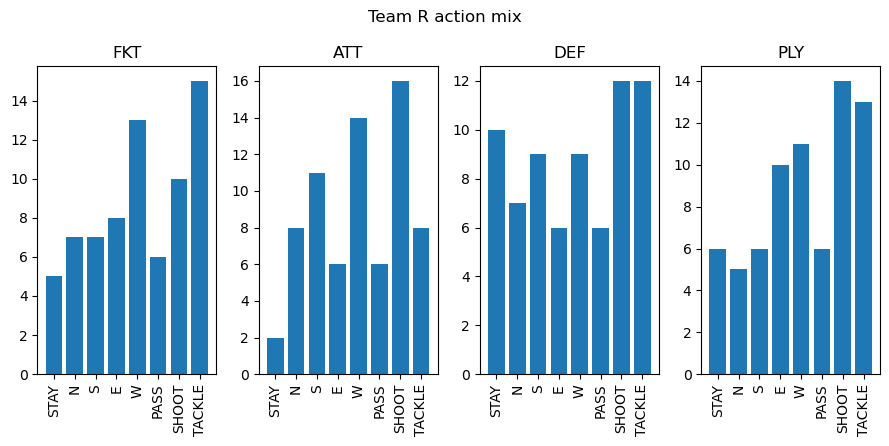

In [16]:
show_action_mix(results["agent_R"], "Team R action mix")


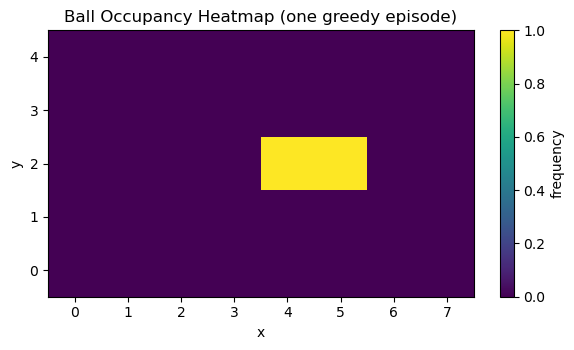

In [17]:
log = play_one_greedy_episode(results["agent_L"], results["agent_R"])
show_ball_heatmap(log)

Trace a single episode (optionally greedy = use argmax, else ε/ random)

In [18]:
def trace_episode(agent_L, agent_R, max_steps=80, seed=123, greedy=False):
    env = SoccerEnv(seed=seed)
    obs = env.reset()
    sL, sR = obs["L"], obs["R"]

    # record positions per step
    trace = {
        "ball":  [(env.ball["x"], env.ball["y"])],
        "L": {role: [(p["x"], p["y"])] for role, p in zip(ROLES, env.tL.players)},
        "R": {role: [(p["x"], p["y"])] for role, p in zip(ROLES, env.tR.players)}
    }

    def greedy_action(agent, s_roles):
        return {role: ACTIONS[int(np.argmax(agent.role_policies[role].Q[s_roles[role]]))] for role in ROLES}

    for t in range(max_steps):
        if greedy:
            aL = greedy_action(agent_L, sL)
            aR = greedy_action(agent_R, sR)
        else:
            # use current policy (ε-greedy) which at the very start behaves almost random
            aL = {role: ACTIONS[agent_L.role_policies[role].act(sL[role])] for role in ROLES}
            aR = {role: ACTIONS[agent_R.role_policies[role].act(sR[role])] for role in ROLES}

        obs2, _, done = env.step(aL, aR)
        sL, sR = obs2["L"], obs2["R"]

        # append positions after step
        trace["ball"].append((env.ball["x"], env.ball["y"]))
        for role, p in zip(ROLES, env.tL.players):
            trace["L"][role].append((p["x"], p["y"]))
        for role, p in zip(ROLES, env.tR.players):
            trace["R"][role].append((p["x"], p["y"]))

        if done:
            break
    return trace

Show the field + trajectories for the *first episode* (static figure)

In [19]:
def show_first_episode(trace, title="First Episode (trajectories)"):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7,4))
    ax = plt.gca()
    ax.set_xlim(-0.5, GRID_W-0.5); ax.set_ylim(-0.5, GRID_H-0.5)
    ax.set_xticks(range(GRID_W)); ax.set_yticks(range(GRID_H))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)

    # draw goals as vertical lines on x=0 and x=GRID_W-1
    ax.axvline(0-0.5, color="k", lw=2, alpha=0.3)
    ax.axvline(GRID_W-1+0.5, color="k", lw=2, alpha=0.3)

    # helper to plot a path
    def plot_path(points, style, label=None, start_marker=None, end_marker=None):
        xs = [p[0] for p in points]; ys = [p[1] for p in points]
        ax.plot(xs, ys, style, lw=2, alpha=0.9, label=label)
        if start_marker:
            ax.plot(xs[0], ys[0], start_marker, ms=10, alpha=0.9)
        if end_marker:
            ax.plot(xs[-1], ys[-1], end_marker, ms=10, alpha=0.9)

    # ball path
    plot_path(trace["ball"], style="-", label="Ball", start_marker="*",
              end_marker="*")

    # team L players (circles)
    for role, pts in trace["L"].items():
        plot_path(pts, style="-o", label=f"L-{role}")

    # team R players (squares)
    for role, pts in trace["R"].items():
        # square markers: draw points ourselves
        xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
        ax.plot(xs, ys, "-", lw=2, alpha=0.9, label=f"R-{role}")
        ax.plot(xs, ys, "s", ms=5, alpha=0.9)

    # make legend compact
    handles, labels = ax.get_legend_handles_labels()
    # unique labels while preserving order
    seen=set(); H=[]; L=[]
    for h,l in zip(handles, labels):
        if l not in seen:
            seen.add(l); H.append(h); L.append(l)
    ax.legend(H, L, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()


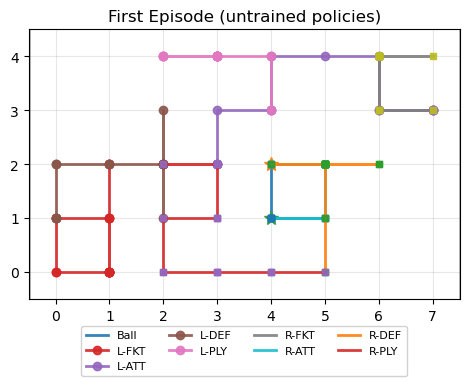

In [20]:
# brand-new teams (before any training) → first episode trace
agent_L0 = TeamAgent('L'); agent_R0 = TeamAgent('R')
# make them very exploratory to emulate "first iteration" randomness
for rp in agent_L0.role_policies.values(): rp.epsilon = 1.0
for rp in agent_R0.role_policies.values(): rp.epsilon = 1.0

trace0 = trace_episode(agent_L0, agent_R0, max_steps=40, seed=1, greedy=False)
show_first_episode(trace0, title="First Episode (untrained policies)")


[Eval @ ep 100] Greedy win rates  L:0.65  R:0.35  Draw:0.00
[Eval @ ep 200] Greedy win rates  L:0.58  R:0.42  Draw:0.00
[Eval @ ep 300] Greedy win rates  L:0.74  R:0.26  Draw:0.00
[Eval @ ep 400] Greedy win rates  L:0.25  R:0.75  Draw:0.00
[Eval @ ep 500] Greedy win rates  L:0.89  R:0.11  Draw:0.00


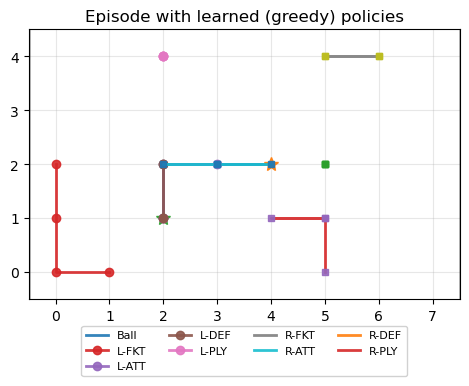

In [21]:
results = train_self_play(episodes=500, max_steps=80, eval_every=100, seed=7)

# greedy = True shows movement with learned argmax actions
trace_learned = trace_episode(results["agent_L"], results["agent_R"], max_steps=40, seed=2, greedy=True)
show_first_episode(trace_learned, title="Episode with learned (greedy) policies")
